# Test linked airglow fits
Run on three trace files with tight and loose priors to see that the fits work and are more tightly linked when priors are tighter.

In [15]:
%matplotlib widget

In [43]:
from pathlib import Path

import emcee
import corner
from scipy.special import gamma
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt

import airglow

In [17]:
test_data_dir = Path("../test-data")
x1d_files = set(test_data_dir.glob("*010*x1d*.fits"))
main_x1d_file = set(test_data_dir.glob("*010*x1d.fits"))
three_trace_files = list(x1d_files - main_x1d_file)

print("Using trace files:")
for file in three_trace_files:
    print(file)


Using trace files:
../test-data/of9b05010_x1dtrace.fits
../test-data/of9b05010_x1dbk1.fits
../test-data/of9b05010_x1dbk2.fits


In [ ]:
# range of pixels to fit
fit_range = [325, 475]

In [32]:

# load the data and put it into lists
pixgrids = []
fluxes = []
errors = []
counts = []
cts_per_flux_factors = []
for file in three_trace_files:
    h = fits.open(file)
    f, e, cps = [h[1].data[s][0] for s in ['flux', 'error', 'gross']]
    x = np.arange(len(f)) + 0.5
    keep = (x > fit_range[0]) & (x < fit_range[1])
    exptime = h[1].header['exptime']
    fluxes.append(f[keep])
    errors.append(e[keep])
    pixgrids.append(x[keep])

    # record factor to estimate counts for a given flux
    cts = cps * exptime
    counts.append(cts[keep])
    cts_per_flux = cts / f
    cts_per_flux_factors.append(cts_per_flux[keep])
    assert np.allclose(cts_per_flux[keep], np.mean(cts_per_flux[keep]), rtol=0.2)
    # if the assertion above fails, it probably means there are some nans or odd pixels that need filling

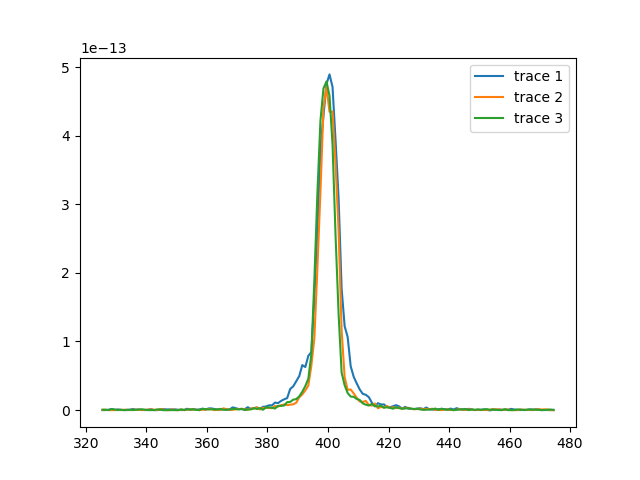

In [33]:
# plot fluxes
plt.figure()
for i, (pixgrid, flux) in enumerate(zip(pixgrids, fluxes)):
    plt.plot(pixgrid, flux, label=f'trace {i+1}')
plt.legend()
plt.show()

In [34]:
# play with purposefully varying the fluxes to see how the fit handles it
fluxes[1] *= 0.9
fluxes[2] *= 1.1

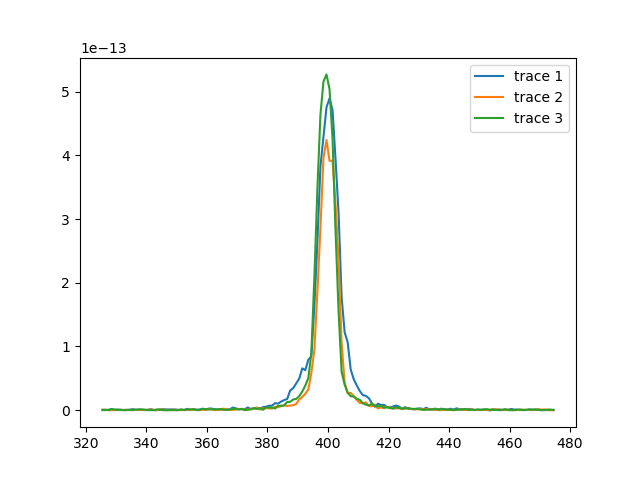

In [35]:
# plot fluxes
plt.figure()
for i, (pixgrid, flux) in enumerate(zip(pixgrids, fluxes)):
    plt.plot(pixgrid, flux, label=f'trace {i+1}')
plt.legend()
plt.show()

In [42]:
# setup runs
sets = ((10, 'loose tolerances'),
        (0.001, 'tight tolerances'))
nburn = 1000
nrun = 10000

center_guesses = [np.average(pixgrid, weights=flux) for flux in fluxes]
amp_guesses = [np.max(flux) for flux in fluxes]
width_guess = 10
midpt_rng = [60, 90]

base_tolerances = [1.0, 2.0, 4e-14, 0.1, 0.1, 1.0e-16]


In [ ]:
models = []
for tol_rel, tol_label in sets:
    # set up a model with tight tolerances
    tolerances = np.array(base_tolerances) * tol_rel
    model = airglow.MultiTraceAirglowModel(
        pixgrids,
        tolerances=tolerances,
        midpt_rng=midpt_rng,
    )
    models.append(model)

    ctstack = np.hstack(counts)
    cts_per_flux_stack = np.hstack(cts_per_flux_factors)
    def loglike(params):
        physical_prior = model.loglike_physical_prior(params)
        if physical_prior == -np.inf:
            return -np.inf
        ys = model.evaluate(params)
        ystack = np.hstack(ys)

        # estimate poisson likelihoods based on the *expected* number of counts predicted from the model
        expected_counts = ystack * cts_per_flux_stack
        # continuous poisson likelihood
        assert np.all(expected_counts > 0)
        loglike_terms = ctstack * np.log(expected_counts) - expected_counts - np.log(gamma(ctstack + 1))

        loglike_data = np.sum(loglike_terms)
        loglike_midpts = model.loglike_midpoint_prior(params)
        loglike_tolerance = model.loglike_tolerance_prior(params)
        return loglike_data + loglike_tolerance + loglike_midpts + physical_prior
        # return loglike_data + loglike_midpts

    np.random.seed(42)

    p0_2d = np.array(((center_guesses[0], width_guess, amp_guesses[0], 0.1, 0.3, 1.0e-16),
                        (center_guesses[1], width_guess, amp_guesses[1], 0.1, 0.3, 1.0e-16),
                        (center_guesses[2], width_guess, amp_guesses[2], 0.1, 0.3, 1.0e-16)))
    p0 = model.params_2d_to_1d(p0_2d.T)
    jitter_amplitude = np.tile((0.01, 0.01, 1e-15, 0.01, 0.01, 1e-18), (3,1))
    jitter_amplitude = model.params_2d_to_1d(jitter_amplitude)
    ndim = len(p0)
    nwalkers = ndim * 3
    jitter = np.random.randn(nwalkers, ndim) * jitter_amplitude
    p0 = p0[None,:] + jitter

    sampler = emcee.EnsembleSampler(nwalkers,  ndim, loglike)
    state = sampler.run_mcmc(p0, nburn, progress=True)
    sampler.reset()
    finalstate = sampler.run_mcmc(state, nrun, progress=True)

    model.sampler = sampler
    model.label = tol_label

/var/folders/6l/1fvgkb5d08b8tf7zpvnzkd7c0000gn/T/ipykernel_68184/1537276720.py:25: RuntimeWarning: invalid value encountered in log
  loglike_terms = ctstack * np.log(expected_counts) - expected_counts - np.log(gamma(ctstack + 1))


ValueError: Probability function returned NaN

In [ ]:
# plot corner for fluxes
fig, axs = plt.subplots(
    len(models[0].param_slices), len(models), 
    figsize=(2*len(models), 2.5 * len(models[0].param_slices)))
for i, model in enumerate(models):
    for j, (name, slc) in enumerate(model.param_slices.items()):
        ax = axs[j,i]
        labels = [f'{name} {i+1}' for i in range(3)]
        model.sampler.flatchain
        corner.corner(sampler.flatchain[:,slc], labels=labels, fig=fig)
        ax.set_title(f'{model.tol_label} {name} posteriors')


In [ ]:
# plot median fits
fig, axs = plt.subplots(len(fluxes), 1, figsize=(5, 4*len(fluxes)))

for i, (flux, pixgrid) in enumerate(zip(fluxes, pixgrids)):
    ax = axs[i]
    ax.step(flux, label='flux', where='mid')
    ax.set_title(f'trace {i+1}')
    ax.legend()

line_styles = ['.-', '--']
for i, model in enumerate(models):
    p_median = np.median(model.sampler.flatchain, axis=0)
    ys = model.evaluate(p_median)
    for i, (pixgrid, flux, y) in enumerate(zip(pixgrids, fluxes, ys)):
        ax.step(pixgrid, y,  where='mid', label=model.label)